<a href="https://colab.research.google.com/github/saradom11/Investigacion-de-operaciones-/blob/main/Tutorial_NetworkX%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div style="background-color:#EAF2F8; padding:20px; border-radius:15px; text-align:center;">

# <font color="#825f87">**Tutorial de NetworkX en Python**</font>

---



## <font color="#856798#d46a7e">Árbol de expansión mínima | Ruta más corta | Flujo máximo</font>

**Materia:** Investigación de Operaciones / Redes  
**Herramienta:** Google Colab  
**Biblioteca:** NetworkX  

<br>

*Tutorial realizado paso a paso con un ejemplo de red.*

</div>


En este cuaderno se explica cómo utilizar la biblioteca <font color="#9e43a2">**NetworkX**</font> de Python para resolver tres problemas clásicos de redes:

1. **Árbol de expansión mínima (MST).**
2. **Ruta más corta.**
3. **Flujo máximo.**

La idea es construir primero la red en Python, visualizarla y después utilizar las funciones de NetworkX para obtener la solución.

---

### <font color="#a55af4">Formulación general</font>

Un grafo puede representarse como:

$$
G=(V,E)
$$

donde:

- $V$ es el conjunto de **nodos**.
- $E$ es el conjunto de **conexiones o arcos**.
- $w_{ij}$ representa el peso, distancia o costo de una conexión.
- $c_{ij}$ representa la capacidad de una conexión en un problema de flujo.

<div style="background:#FDF2E9; padding:12px; border-left:5px solid #E67E22;">
<b>Nota:</b> En este ejercicio se utilizan los nodos y valores que aparecen en las imágenes proporcionadas para la actividad.
</div>


---


### <font color="#a55af4">1. ¿Qué es NetworkX? </font>

**NetworkX** es una biblioteca de Python para crear, manipular, visualizar y analizar redes y grafos.

Algunas estructuras importantes son:

| Comando | Significado |
|---|---|
| `nx.Graph()` | Grafo no dirigido |
| `nx.DiGraph()` | Grafo dirigido |
| `add_node()` | Agregar un nodo |
| `add_edge()` | Agregar una arista |
| `add_weighted_edges_from()` | Agregar varias aristas con pesos |
| `nx.draw()` | Dibujar el grafo |
| `nx.minimum_spanning_tree()` | Obtener árbol de expansión mínima |
| `nx.shortest_path()` | Encontrar una ruta |
| `nx.shortest_path_length()` | Obtener la longitud/costo de una ruta |
| `nx.maximum_flow()` | Calcular el flujo máximo |

La documentación oficial de NetworkX explica que los objetos `Graph` representan pares de nodos unidos por aristas y que los atributos de las aristas pueden utilizarse para guardar pesos, capacidades u otros datos.


---

### <font color="#856798#d46a7e">📚 Material de consulta </font>

- **Documentación oficial de NetworkX:**  
  https://networkx.org/documentation/stable/

- **Tutorial oficial:**  
  https://networkx.org/documentation/stable/tutorial.html

- **Galería de ejemplos:**  
  https://networkx.org/documentation/stable/auto_examples/index.html

- **Video sobre rutas más cortas con NetworkX:**  
  https://www.youtube.com/watch?v=TkMCFjq-Yqs

- **Video sobre flujo máximo con NetworkX:**  
  https://www.youtube.com/watch?v=XUN5NOdjmdE

Estos recursos sirven como apoyo para entender la sintaxis y consultar otras funciones.


---

### <font color="#a55af4">2. Preparación del ambiente </font>
Primero importamos las bibliotecas que vamos a utilizar.

`networkx` será la biblioteca principal para trabajar con redes y `matplotlib` se utilizará para realizar los dibujos.


In [1]:
# Instalamos NetworkX
!pip install networkx matplotlib -q

# Importamos las bibliotecas
import networkx as nx
import matplotlib.pyplot as plt

print("NetworkX:", nx.__version__)


NetworkX: 3.7



### <font color="#a55af4">3. Instrucciones básicas </font>

Una de las ventajas de NetworkX es que podemos construir una red de manera bastante directa.

Por ejemplo:

```python
G = nx.Graph()
G.add_edge(1, 2, weight=5)
```

La instrucción anterior crea una conexión entre los nodos 1 y 2 y le asigna un peso de 5.

Para una red dirigida utilizamos:

```python
G = nx.DiGraph()
```

En un `DiGraph`, la conexión `(1,2)` significa específicamente:

$$
1\rightarrow2
$$

por lo que la dirección de las aristas sí importa.


---

### <font color="#a55af4">4. Redes utilizadas en esta actividad </font>


### Actividad 1_a:

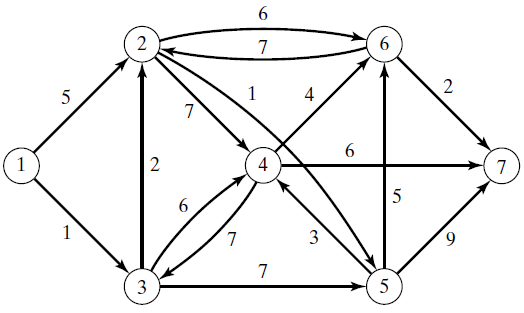

In [2]:
from IPython.display import Image, display

# Muestra la imagen local controlando el tamaño
display(Image(filename='/content/actividad_1_a.png', width=500))


### Actividad 1_b:

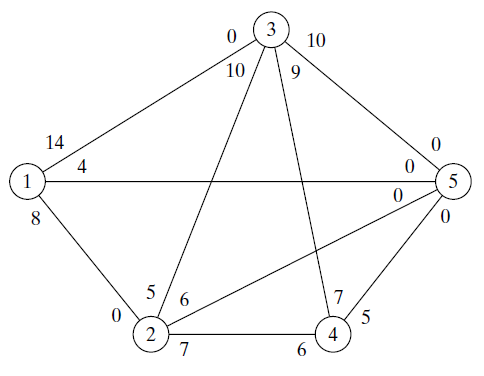

In [3]:
from IPython.display import Image, display

# Muestra la imagen local controlando el tamaño
display(Image(filename='/content/actividad_1_b.png', width=500))


---
---

# <font color="#856798"> I - Árbol de expansión mínima </font>

### <font color="#a55af4">5. ¿Qué es un árbol de expansión mínima? </font>

Un **árbol de expansión mínima** es un conjunto de las arcos de una red no dirigida que:

- conecta todos los nodos,
- no contiene ciclos,
- utiliza exactamente $|V|-1$ aristas,
- y minimiza la suma de los pesos.

Su formulación puede escribirse como:

$$
\min \sum_{(i,j)\in E} w_{ij}x_{ij}
$$

sujeto a que los arcos seleccionadas formen un árbol que conecte todos los nodos.

### En esta actividad

La instrucción indica que para el árbol de expansión mínima debemos utilizar la **versión no dirigida** de la red de `actividad_1_a`.

Por eso, aunque la imagen tiene flechas, se ignorará la dirección y conservaremos el menor peso cuando existan dos conexiones entre el mismo par de nodos.

NetworkX ofrece directamente:

```python
nx.minimum_spanning_tree(G)
```

La función recibe un grafo no dirigido y devuelve un árbol de expansión mínima.


---

### <font color="#a55af4">6. Construcción de la red de la actividad 1.a </font>

Primero registramos las aristas de la imagen original.

La sintaxis:

```python
(1, 2, 5)
```

significa:

- nodo inicial: `1`
- nodo final: `2`
- peso: `5`

Para la versión dirigida usamos `DiGraph()`.


In [4]:

# Red original de la actividad 1a
G = nx.DiGraph()

aristas = [(1, 2, 5),
    (1, 3, 1),
    (3, 2, 2),
    (2, 4, 7),
    (3, 4, 6),
    (4, 3, 7),
    (2, 5, 1),
    (5, 4, 3),
    (2, 6, 6),
    (6, 2, 7),
    (4, 6, 4),
    (3, 5, 7),
    (5, 6, 5),
    (6, 7, 2),
    (4, 7, 6),
    (5, 7, 9)]

G.add_weighted_edges_from(aristas)

print("Nodos:", list(G.nodes()))
print("Número de aristas:", G.number_of_edges())


Nodos: [1, 2, 3, 4, 5, 6, 7]
Número de aristas: 16


---

### <font color="#a55af4">7. Dibujamos la red </font>

Para que el dibujo se parezca a la red de la actividad, definimos manualmente la posición de los nodos.

`pos` es un diccionario que indica dónde colocar cada nodo.

`nx.draw_networkx_edge_labels()` permite mostrar los pesos sobre las aristas.


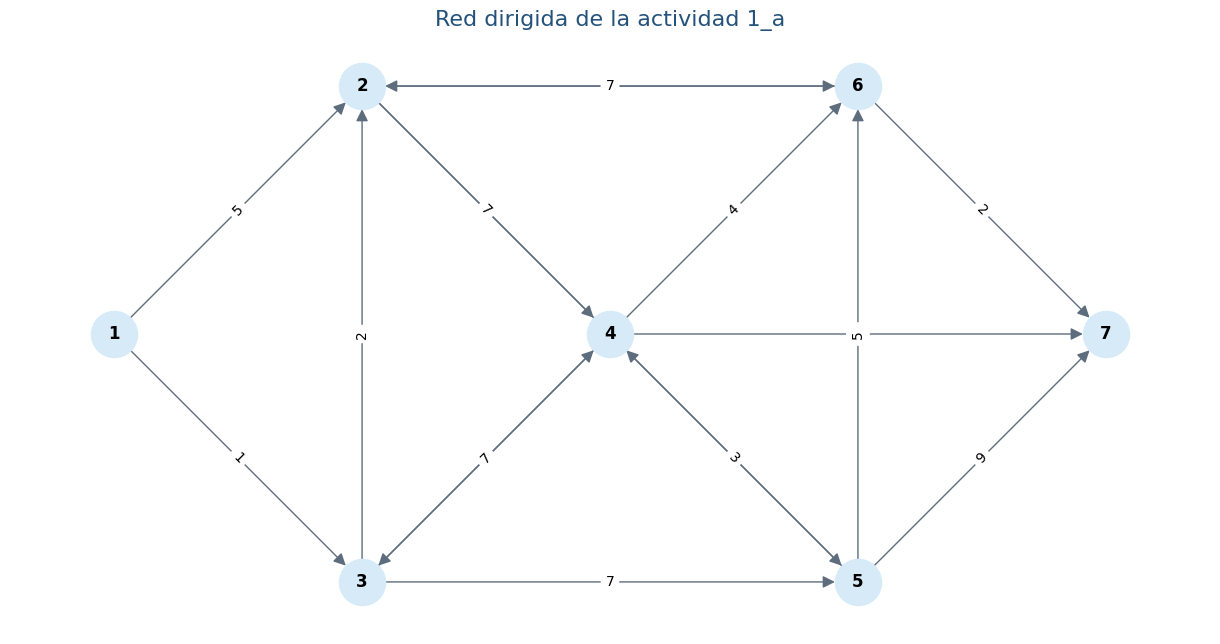

In [5]:

# Posiciones aproximadas a las de la imagen
pos = {
    1: (0, 1.5),
    2: (2, 3),
    3: (2, 0),
    4: (4, 1.5),
    5: (6, 0),
    6: (6, 3),
    7: (8, 1.5)
}

plt.figure(figsize=(12, 6))

nx.draw(G, pos,with_labels=True,node_color="#D6EAF8",node_size=1100,font_size=12,font_weight="bold",arrows=True,edge_color="#5D6D7E",arrowsize=18)
etiquetas = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos,edge_labels=etiquetas,font_size=10)

plt.title("Red dirigida de la actividad 1_a", fontsize=16, color="#24527A")
plt.axis("off")
plt.show()


---

### <font color="#a55af4"> 8. Convertir la red a una versión no dirigida </font>

Para el Árbol necesitamos un `Graph()`.

Detalle importante: en la red original existen conexiones en ambos sentidos, por ejemplo:

$$
2\rightarrow6 \quad (6)
$$

y

$$
6\rightarrow2 \quad (7)
$$

Al quitar la dirección, ambas representarían la misma conexión $2-6$. Para el MST conservamos el **menor peso**, que es 6.

Lo mismo sucede con $3-4$, donde se tienen pesos 6 y 7, por lo que conservamos 6.


In [6]:

# Creamos el grafo no dirigido
G_no_dirigido = nx.Graph()

for u, v, peso in aristas:
    # Si ya existe la conexión, conservamos el peso menor
    if G_no_dirigido.has_edge(u, v):
        if peso < G_no_dirigido[u][v]["weight"]:
            G_no_dirigido[u][v]["weight"] = peso
    else:
        G_no_dirigido.add_edge(u, v, weight=peso)

print("Aristas de la versión no dirigida:")
for u, v, datos in G_no_dirigido.edges(data=True):
    print(f"{u} -- {v} : peso = {datos['weight']}")


Aristas de la versión no dirigida:
1 -- 2 : peso = 5
1 -- 3 : peso = 1
2 -- 3 : peso = 2
2 -- 4 : peso = 7
2 -- 5 : peso = 1
2 -- 6 : peso = 6
3 -- 4 : peso = 6
3 -- 5 : peso = 7
4 -- 5 : peso = 3
4 -- 6 : peso = 4
4 -- 7 : peso = 6
5 -- 6 : peso = 5
5 -- 7 : peso = 9
6 -- 7 : peso = 2


---

### <font color="#a55af4">9. Obtener el árbol de expansión mínima </font>

La función principal es:

```python
T = nx.minimum_spanning_tree(G_no_dirigido)
```

NetworkX permite especificar el algoritmo; por defecto utiliza **Kruskal**. También existen las opciones `prim` y `boruvka`.

En nuestro caso utilizaremos el predeterminado.


In [7]:

# Árbol de expansión mínima
T = nx.minimum_spanning_tree(G_no_dirigido,weight="weight")
print("Aristas seleccionadas por el MST:\n")

costo_total = 0
for u, v, datos in sorted(T.edges(data=True)):
    peso = datos["weight"]
    costo_total += peso
    print(f"{u} -- {v}   peso = {peso}")

print("\nCosto total del árbol =", costo_total)


Aristas seleccionadas por el MST:

1 -- 3   peso = 1
2 -- 3   peso = 2
2 -- 5   peso = 1
4 -- 5   peso = 3
4 -- 6   peso = 4
6 -- 7   peso = 2

Costo total del árbol = 13


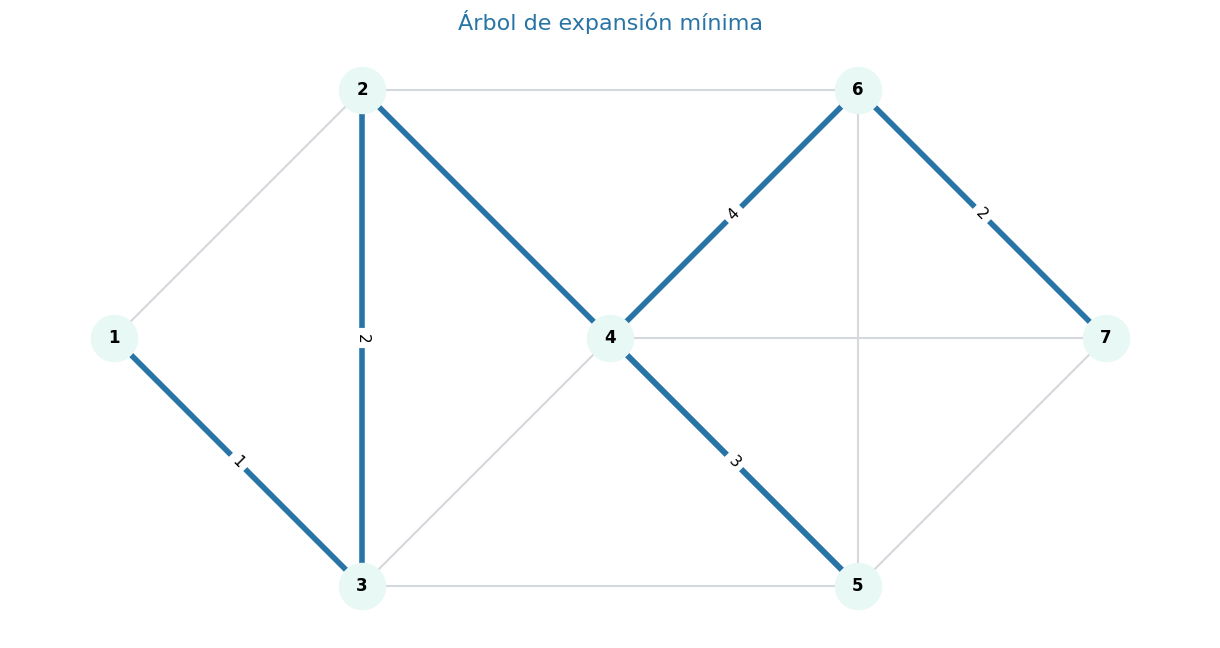

In [8]:

# Dibujamos el MST
plt.figure(figsize=(12, 6))
nx.draw(G_no_dirigido, pos,with_labels=True,node_color="#E8F8F5",node_size=1100,font_size=12,font_weight="bold",edge_color="#D5D8DC",width=1.5)
nx.draw_networkx_edges(T, pos,edge_color="#2874A6",width=4)

etiquetas_T = nx.get_edge_attributes(T, "weight")
nx.draw_networkx_edge_labels(T, pos,edge_labels=etiquetas_T,font_size=11)

plt.title("Árbol de expansión mínima", fontsize=16, color="#2874A6")
plt.axis("off")
plt.show()


---

### <font color="#ad0afd">✓ Resultado del árbol de expansión mínima </font>

Las aristas seleccionadas son:

$$
\boxed{
(1,3),\ (2,5),\ (2,3),\ (4,5),\ (4,6),\ (6,7)
}
$$

con pesos:

$$
1+1+2+3+4+2=\boxed{13}
$$

Por lo tanto:

> **El costo mínimo del árbol de expansión es 13.**

Además, se utilizan 6 aristas para conectar los 7 nodos, como debe ocurrir en un árbol:

$$
|V|-1=7-1=6.
$$


---
---

# <font color="#856798"> II — RUTA MÁS CORTA </font>

### <font color="#a55af4">10. ¿Qué es la ruta más corta? </font>

El problema de la ruta más corta consiste en encontrar un camino entre un nodo origen y un nodo destino minimizando la suma de los pesos de sus arcos.

Si una ruta $P$ está formada por el arco $(i,j)$, su costo es:

$$
C(P)=\sum_{(i,j)\in P}w_{ij}
$$

En NetworkX podemos utilizar:

```python
nx.shortest_path()
```

y para obtener solamente el costo:

```python
nx.shortest_path_length()
```

La función `shortest_path()` puede utilizar Dijkstra cuando los pesos son no negativos, como sucede en nuestra red.


---
### <font color="#a55af4">11.¿De qué nodo a qué nodo? </font>

Para este ejercicio tome:

- **Origen:** nodo 1
- **Destino:** nodo 7

Esto permite encontrar la ruta de extremo a extremo en la red.


In [9]:

origen = 1
destino = 7

ruta = nx.shortest_path(G,source=origen,target=destino,weight="weight")
distancia = nx.shortest_path_length(G,source=origen,target=destino,weight="weight")
print("Ruta más corta:", ruta)
print("Costo de la ruta:", distancia)


Ruta más corta: [1, 3, 2, 6, 7]
Costo de la ruta: 11


In [10]:

# Calculamos los pesos de cada tramo de la ruta
print("Desglose de la ruta:\n")

for i in range(len(ruta) - 1):
    u = ruta[i]
    v = ruta[i + 1]
    peso = G[u][v]["weight"]
    print(f"{u} -> {v} = {peso}")

print("\nSuma total =", distancia)


Desglose de la ruta:

1 -> 3 = 1
3 -> 2 = 2
2 -> 6 = 6
6 -> 7 = 2

Suma total = 11


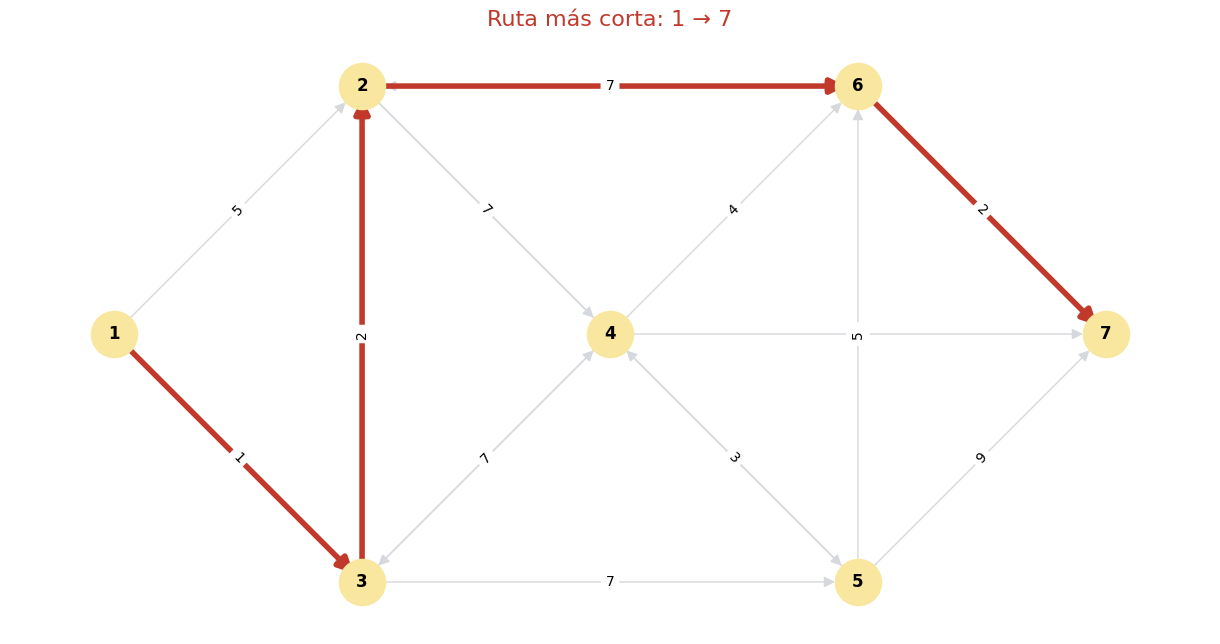

In [11]:

# Dibujamos la ruta más corta resaltada
plt.figure(figsize=(12, 6))

nx.draw(G, pos,with_labels=True,node_color="#F9E79F",node_size=1100,font_size=12,font_weight="bold",edge_color="#D5D8DC",arrows=True,arrowsize=16)

# Convertimos la ruta en pares de arcos
arcos_ruta = list(zip(ruta[:-1], ruta[1:]))
nx.draw_networkx_edges(G, pos,edgelist=arcos_ruta,edge_color="#C0392B",width=4,arrows=True,arrowsize=22)
etiquetas = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos,edge_labels=etiquetas,font_size=10)

plt.title("Ruta más corta: 1 → 7", fontsize=16, color="#C0392B")
plt.axis("off")
plt.show()


---
### <font color=" #ad0afd"> ✓ Resultado de la ruta más corta </font>

NetworkX obtiene:

$$
1\rightarrow3\rightarrow2\rightarrow6\rightarrow7
$$

El costo es:

$$
1+2+6+2=\boxed{11}
$$

Por lo tanto:

> **La ruta más corta desde el nodo 1 hasta el nodo 7 es 1 → 3 → 2 → 6 → 7, con costo mínimo 11.**


---
---
# <font color="#856798"> III — FLUJO MÁXIMO </font>

### <font color="#a55af4">12. ¿Qué es el problema de flujo máximo? </font>

En una red de flujo tenemos:

- una **fuente** $s$,
- un **sumidero** $t$,
- arcos dirigidos,
- y una capacidad máxima $c_{ij}$ para cada arista.

El objetivo es enviar la mayor cantidad posible de flujo desde $s$ hasta $t$ sin superar las capacidades.

La restricción básica es:

$$
0\leq f_{ij}\leq c_{ij}
$$

y en cada nodo intermedio se debe cumplir conservación de flujo:

$$
\sum f_{\text{entra}}
=
\sum f_{\text{sale}}
$$

NetworkX utiliza la función:

```python
nx.maximum_flow(G, s, t)
```

La función devuelve dos resultados:

1. el **valor del flujo máximo**;
2. un diccionario con el flujo utilizado en cada arco.

La documentación actual de NetworkX indica que las capacidades se guardan normalmente en el atributo de arista llamado `"capacity"`.


---
### <font color="#a55af4">13. Interpretación de la actividad 1_b </font>

En la imagen de la actividad 1_b aparecen dos valores junto a las conexiones.

Para resolver específicamente el **flujo máximo**, utilizaremos como **capacidad** el mayor valor indicado para cada conexión. Los valores menores que aparecen en la imagen no intervienen en el cálculo del flujo máximo; pueden interpretarse como información adicional de la red, por ejemplo costos.

Tomamos como:

- **Fuente:** nodo 1
- **Sumidero:** nodo 5

Las capacidades utilizadas son:

| Arista | Capacidad |
|---|---:|
| 1 → 3 | 14 |
| 1 → 2 | 8 |
| 1 → 5 | 4 |
| 3 → 2 | 10 |
| 3 → 4 | 9 |
| 3 → 5 | 10 |
| 2 → 4 | 7 |
| 2 → 5 | 6 |
| 4 → 5 | 5 |

<div style="background:#F4ECF7; padding:12px; border-left:5px solid #8E44AD;">
<b>Importante:</b> En un problema de flujo máximo, la capacidad es el límite superior que puede circular por un arco.
</div>


In [12]:

# Creamos el grafo dirigido para flujo máximo
F = nx.DiGraph()

capacidades = [
    (1, 3, 14),
    (1, 2, 8),
    (1, 5, 4),
    (3, 2, 10),
    (3, 4, 9),
    (3, 5, 10),
    (2, 4, 7),
    (2, 5, 6),
    (4, 5, 5)
]

# Guardamos cada capacidad con el atributo "capacity"
for u, v, capacidad in capacidades:
    F.add_edge(u, v, capacity=capacidad)

print("Aristas y capacidades:")
for u, v, datos in F.edges(data=True):
    print(f"{u} -> {v}: capacidad = {datos['capacity']}")


Aristas y capacidades:
1 -> 3: capacidad = 14
1 -> 2: capacidad = 8
1 -> 5: capacidad = 4
3 -> 2: capacidad = 10
3 -> 4: capacidad = 9
3 -> 5: capacidad = 10
2 -> 4: capacidad = 7
2 -> 5: capacidad = 6
4 -> 5: capacidad = 5


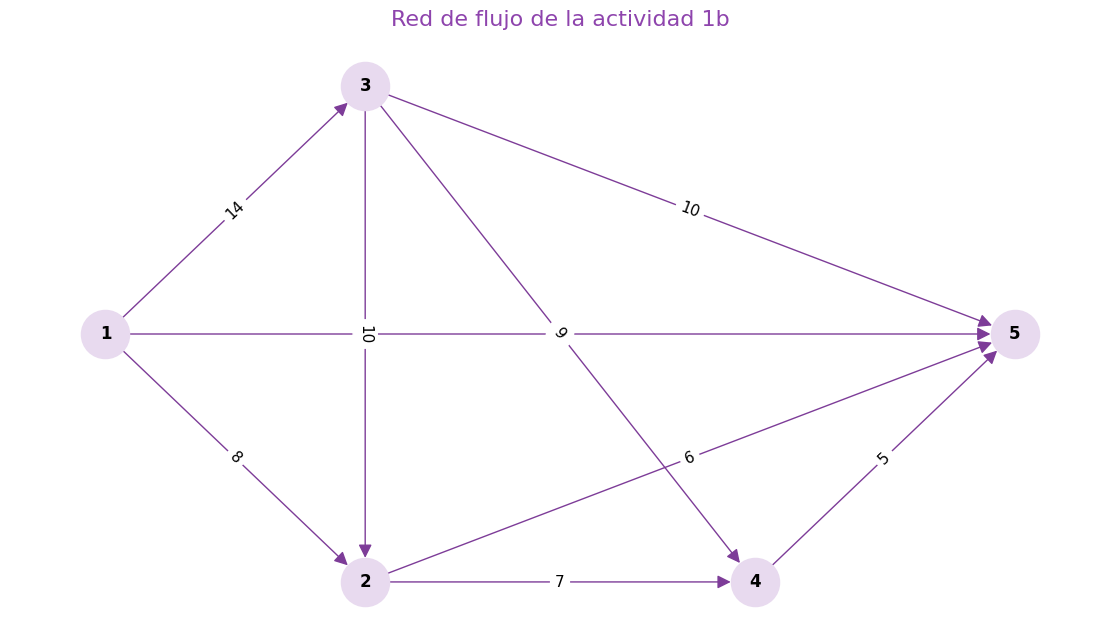

In [13]:

# Posiciones para dibujar la red de flujo
pos_flujo = {
    1: (0, 1.5),
    2: (2, 0),
    3: (2, 3),
    4: (5, 0),
    5: (7, 1.5)
}

plt.figure(figsize=(11, 6))

nx.draw(
    F, pos_flujo,
    with_labels=True,
    node_color="#E8DAEF",
    node_size=1200,
    font_size=12,
    font_weight="bold",
    edge_color="#7D3C98",
    arrows=True,
    arrowsize=20
)

etiquetas_capacidad = nx.get_edge_attributes(F, "capacity")

nx.draw_networkx_edge_labels(
    F, pos_flujo,
    edge_labels=etiquetas_capacidad,
    font_size=11
)

plt.title("Red de flujo de la actividad 1b", fontsize=16, color="#8E44AD")
plt.axis("off")
plt.show()


---
### <font color="#a55af4">14. Calcular el flujo máximo 1_b </font>

La instrucción principal es:

```python
valor_flujo, flujo = nx.maximum_flow(F, 1, 5)
```

Aquí:

- `F` es nuestra red.
- `1` es la fuente.
- `5` es el sumidero.
- `valor_flujo` guarda el valor total del flujo máximo.
- `flujo` contiene cuánto flujo circula por cada arista.

No necesitamos implementar manualmente Ford-Fulkerson para obtener la respuesta; NetworkX se encarga del algoritmo.


In [14]:
# Calculamos el flujo máximo
fuente = 1
sumidero = 5

valor_flujo, flujo = nx.maximum_flow(
    F,
    fuente,
    sumidero,
    capacity="capacity"
)

print("Valor del flujo máximo =", valor_flujo)
print("\nFlujo utilizado en cada arista:\n")

for u in flujo:
    for v in flujo[u]:
        print(f"{u} -> {v}: {flujo[u][v]}")


Valor del flujo máximo = 25

Flujo utilizado en cada arista:

1 -> 3: 13
1 -> 2: 8
1 -> 5: 4
3 -> 2: 0
3 -> 4: 3
3 -> 5: 10
2 -> 4: 2
2 -> 5: 6
4 -> 5: 5


In [15]:

# Mostramos capacidad y flujo en una tabla sencilla
print("Arista        Capacidad     Flujo")
print("-" * 38)

for u, v, datos in F.edges(data=True):
    capacidad = datos["capacity"]
    cantidad = flujo[u][v]
    print(f"{u} -> {v}          {capacidad:>3}          {cantidad:>3}")


Arista        Capacidad     Flujo
--------------------------------------
1 -> 3           14           13
1 -> 2            8            8
1 -> 5            4            4
3 -> 2           10            0
3 -> 4            9            3
3 -> 5           10           10
2 -> 4            7            2
2 -> 5            6            6
4 -> 5            5            5


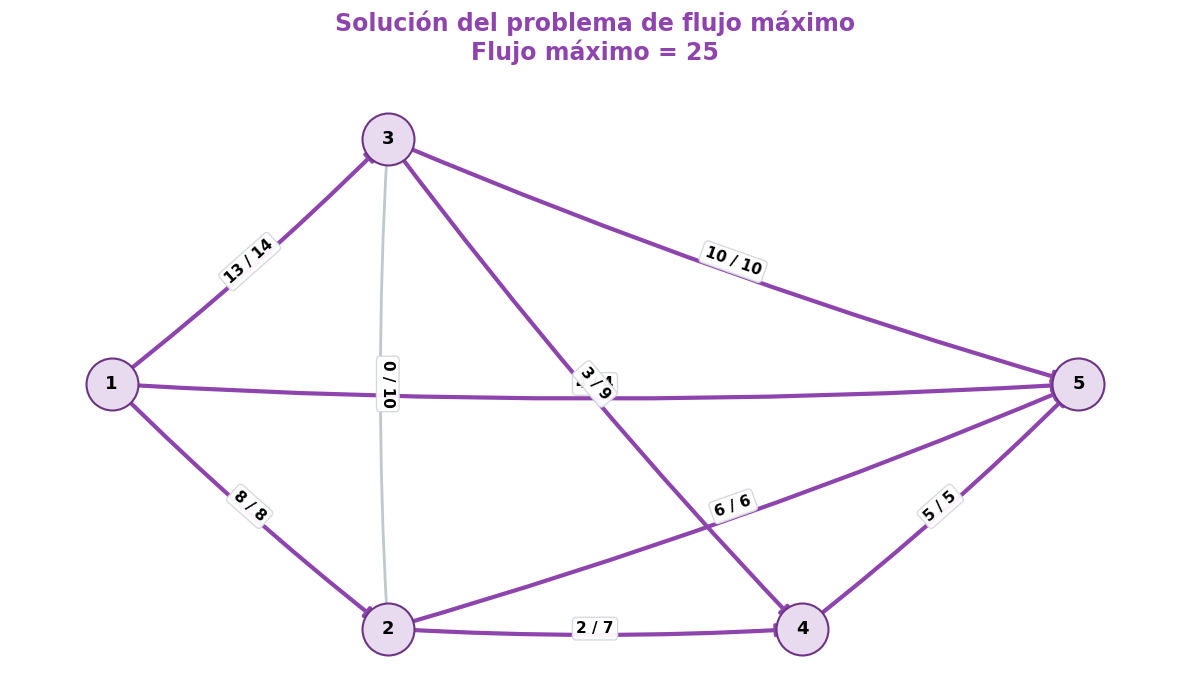

In [19]:

# Dibujamos la solución del flujo máximo
plt.figure(figsize=(12, 7))

nx.draw_networkx_nodes(F, pos_flujo, node_color="#E8DAEF", node_size=1400, edgecolors="#6C3483",linewidths=1.5)
nx.draw_networkx_labels( F, pos_flujo,font_size=13,font_weight="bold")
nx.draw_networkx_edges( F, pos_flujo, edge_color="#BFC9CA", width=2,arrows=True, arrowsize=16,connectionstyle="arc3,rad=0.03")

aristas_con_flujo = [(u, v) for u, v in F.edges() if flujo[u][v] > 0]

nx.draw_networkx_edges(F, pos_flujo,edgelist=aristas_con_flujo, edge_color="#8E44AD", width=3, arrows=True, arrowsize=18, connectionstyle="arc3,rad=0.03")

etiquetas_flujo = {}

for u, v in F.edges():
    cantidad_flujo = flujo[u][v]
    capacidad = F[u][v]["capacity"]
    etiquetas_flujo[(u, v)] = f"{cantidad_flujo} / {capacidad}"


nx.draw_networkx_edge_labels(F,pos_flujo,edge_labels=etiquetas_flujo,font_size=11,font_weight="bold",label_pos=0.5,bbox=dict(facecolor="white", edgecolor="#D5D8DC",boxstyle="round,pad=0.25",alpha=0.95 ))


plt.title(
    f"Solución del problema de flujo máximo\n"
    f"Flujo máximo = {valor_flujo}",
    fontsize=17,
    fontweight="bold",
    color="#8E44AD",
    pad=20
)


plt.axis("off")
plt.tight_layout()
plt.show()



### <span style="color:#8E44AD;">✓ Resultado del flujo máximo</span>

El programa obtiene:

$$
\boxed{F_{\max}=25}
$$

Una solución de flujo encontrada es:

- $1\rightarrow3$: 13
- $1\rightarrow2$: 8
- $1\rightarrow5$: 4
- $3\rightarrow4$: 3
- $3\rightarrow5$: 10
- $2\rightarrow4$: 2
- $2\rightarrow5$: 6
- $4\rightarrow5$: 5

La salida desde la fuente es:

$$
13+8+4=25
$$

y la entrada al sumidero es:

$$
10+6+5+4=25.
$$

Por lo tanto, se cumple la conservación y:

> **El flujo máximo de la red es 25 unidades.**


---
### <font color="#a55af4">15. Resumen de comandos utilizados 1_b </font>

| Problema | Función principal | Resultado |
|---|---|---:|
| Árbol de expansión mínima | `nx.minimum_spanning_tree()` | Costo = **13** |
| Ruta más corta | `nx.shortest_path()` | Ruta = **1 → 3 → 2 → 6 → 7** |
| Ruta más corta | `nx.shortest_path_length()` | Costo = **11** |
| Flujo máximo | `nx.maximum_flow()` | Flujo = **25** |

### Ideas principales

**1. Árbol de expansión mínima**

Se busca conectar todos los nodos con el menor costo posible y sin formar ciclos.

**2. Ruta más corta**

Se busca el camino de menor costo entre un origen y un destino.

**3. Flujo máximo**

Se busca enviar la mayor cantidad posible desde una fuente hasta un sumidero respetando las capacidades de las aristas.


---
### <font color="#a55af4">16. Conclusiones </font>

NetworkX facilita la solución de problemas clásicos de teoría de redes porque permite representar directamente los nodos, las aristas y sus atributos.

En la actividad realizada se obtuvieron los siguientes resultados:

### 🟦 Árbol de expansión mínima

$$
\boxed{\text{Costo mínimo}=13}
$$

### 🟩 Ruta más corta de 1 a 7

$$
\boxed{1\rightarrow3\rightarrow2\rightarrow6\rightarrow7}
$$

con:

$$
\boxed{\text{Costo}=11}
$$

### 🟪 Flujo máximo de 1 a 5

$$
\boxed{\text{Flujo máximo}=25}
$$

Estos resultados fueron obtenidos utilizando las funciones de NetworkX y posteriormente se verificaron mediante las propiedades de cada problema.



## Referencias

**Documentación oficial de NetworkX**

https://networkx.org/documentation/stable/

**Tutorial oficial de NetworkX**

https://networkx.org/documentation/stable/tutorial.html

**Documentación: árboles de expansión mínima**

https://networkx.org/documentation/stable/reference/algorithms/tree.html

**Documentación: ruta más corta**

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path.html

**Documentación: flujo máximo**

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.flow.maximum_flow.html

**Video: Shortest Path in NetworkX**

https://www.youtube.com/watch?v=TkMCFjq-Yqs

**Video: Maximum Flow con NetworkX**

https://www.youtube.com/watch?v=XUN5NOdjmdE
